<a href="https://colab.research.google.com/github/komazawa-deep-learning/komazawa-deep-learning.github.io/blob/master/2026notebooks/2026ai_lect03a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 人工知能I 第3回：線形回帰と多変量回帰

**担当**: 浅川伸一  
**2026年度 前期**

---

## 構成

**前半（実習①）**
1. 線形回帰の基本
2. 手動でのパラメータ理解
3. 最小二乗法の実装
4. scikit-learnによる実装
5. 評価と可視化

**後半（実習②）**
6. 多変量回帰
7. 多重共線性の確認
8. 過学習のデモ
9. Ridge回帰
10. Lasso回帰
11. 3手法の総合比較

---
## 0. 環境準備

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_diabetes

!pip install japanize-matplotlib --quiet
import japanize_matplotlib

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')

print("環境準備完了")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 21.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
環境準備完了


---
# 前半：線形回帰の基礎（実習①）

## 1. 問題設定と理論

**線形回帰の数式**：$y = wx + b$

- $w$：重み（weight）= 直線の傾き
- $b$：バイアス（bias）= 直線の切片

**最小二乗法**：誤差の二乗和 $L = \frac{1}{n}\sum(y_i - \hat{y}_i)^2$ を最小化するw，bを求める

**評価指標**
- MSE（Mean Squared Error）：誤差の二乗平均，小さいほど良い
- R²（決定係数）：0〜1，1に近いほど良い

## 2. データの準備と可視化

In [3]:
# 実習①データ：勉強時間と試験成績
study_hours = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=float)
test_scores  = np.array([45, 55, 60, 65, 70, 75, 80, 85, 88, 92], dtype=float)

df = pd.DataFrame({'勉強時間（h）': study_hours, '試験成績（点）': test_scores})
print("=== データ ===")
print(df.to_string(index=False))
print(f"\n記述統計\n{df.describe().round(2)}")

=== データ ===
 勉強時間（h）  試験成績（点）
     1.0     45.0
     2.0     55.0
     3.0     60.0
     4.0     65.0
     5.0     70.0
     6.0     75.0
     7.0     80.0
     8.0     85.0
     9.0     88.0
    10.0     92.0

記述統計
       勉強時間（h）  試験成績（点）
count    10.00    10.00
mean      5.50    71.50
std       3.03    15.31
min       1.00    45.00
25%       3.25    61.25
50%       5.50    72.50
75%       7.75    83.75
max      10.00    92.00


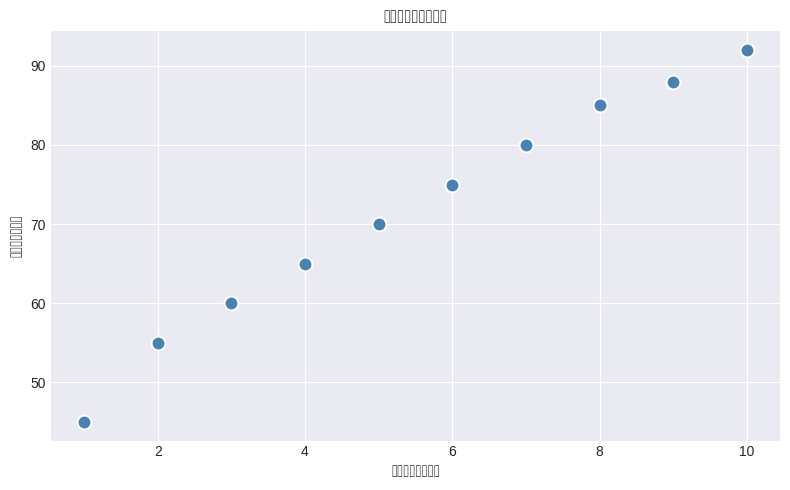

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(study_hours, test_scores, s=100, color='steelblue', edgecolors='white', linewidth=1.5)
plt.xlabel('勉強時間（時間）', fontsize=12)
plt.ylabel('試験成績（点）', fontsize=12)
plt.title('勉強時間と試験成績', fontsize=14)
plt.tight_layout()
plt.show()

## 3. パラメータを手動で設定：w と b の役割を理解する

w（傾き）と b（切片）を変えると予測直線がどう変わるかを確認します。

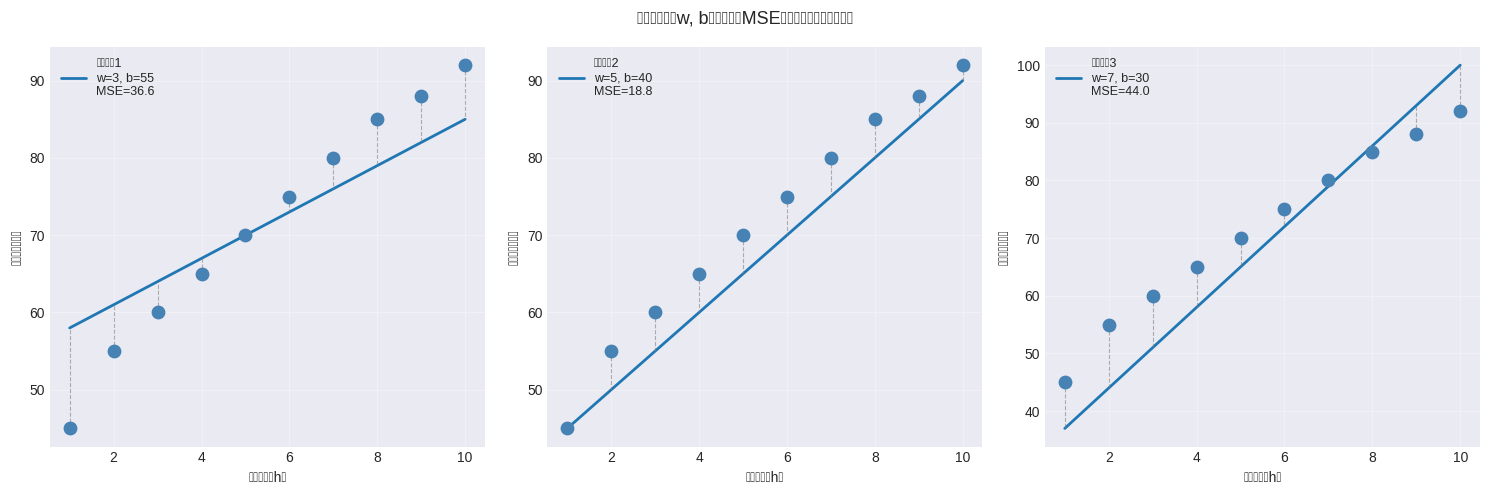

MSEが最小のモデルを選びたい → 最小二乗法で自動的に求める


In [5]:
def plot_model_with_mse(w, b, ax, label):
    """パラメータを受け取って予測直線とMSEを表示"""
    y_pred = w * study_hours + b
    mse = np.mean((test_scores - y_pred) ** 2)
    ax.scatter(study_hours, test_scores, s=80, color='steelblue', zorder=5)
    ax.plot(study_hours, y_pred, linewidth=2,
            label=f'{label}\nw={w}, b={b}\nMSE={mse:.1f}')
    # 残差を破線で表示
    for xi, yi, yp in zip(study_hours, test_scores, y_pred):
        ax.plot([xi, xi], [yi, yp], 'gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_xlabel('勉強時間（h）')
    ax.set_ylabel('試験成績（点）')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_model_with_mse(w=3,  b=55, ax=axes[0], label='パターン1')
plot_model_with_mse(w=5,  b=40, ax=axes[1], label='パターン2')
plot_model_with_mse(w=7,  b=30, ax=axes[2], label='パターン3')
plt.suptitle('パラメータ（w, b）の影響：MSEが最小になるものが最良', fontsize=13)
plt.tight_layout()
plt.show()

print("MSEが最小のモデルを選びたい → 最小二乗法で自動的に求める")

## 4. 最小二乗法：数式でw，bを計算する

$$w = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sum(x_i - \bar{x})^2}, \quad b = \bar{y} - w\bar{x}$$

=== 最小二乗法による結果 ===
w（傾き）  = 5.0242
b（切片）  = 43.8667
式        : y = 5.0242x + 43.8667
MSE        = 2.7952


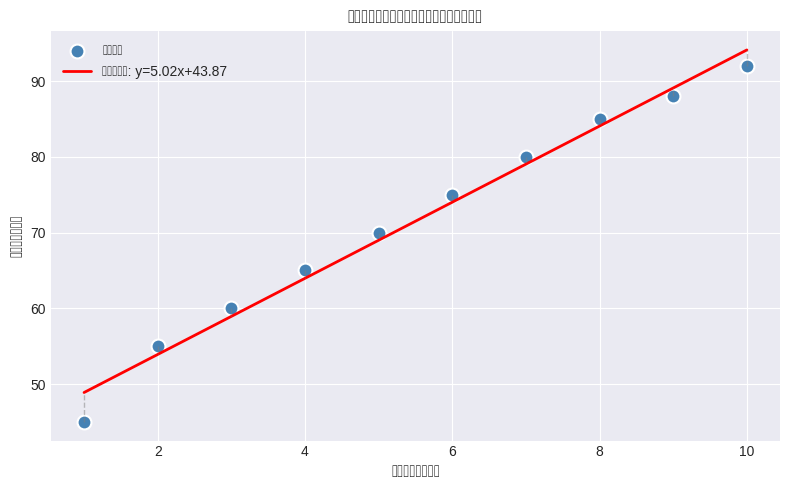

In [6]:
x_mean = np.mean(study_hours)
y_mean = np.mean(test_scores)

w_ols = np.sum((study_hours - x_mean) * (test_scores - y_mean)) / \
        np.sum((study_hours - x_mean) ** 2)
b_ols = y_mean - w_ols * x_mean

y_pred_ols = w_ols * study_hours + b_ols
mse_ols    = np.mean((test_scores - y_pred_ols) ** 2)

print("=== 最小二乗法による結果 ===")
print(f"w（傾き）  = {w_ols:.4f}")
print(f"b（切片）  = {b_ols:.4f}")
print(f"式        : y = {w_ols:.4f}x + {b_ols:.4f}")
print(f"MSE        = {mse_ols:.4f}")

# 可視化
plt.figure(figsize=(8, 5))
plt.scatter(study_hours, test_scores, s=100, color='steelblue',
            edgecolors='white', linewidth=1.5, label='実データ')
plt.plot(study_hours, y_pred_ols, 'r-', linewidth=2,
         label=f'最小二乗法: y={w_ols:.2f}x+{b_ols:.2f}')
for xi, yi, yp in zip(study_hours, test_scores, y_pred_ols):
    plt.plot([xi, xi], [yi, yp], 'gray', linestyle='--', linewidth=1, alpha=0.5)
plt.xlabel('勉強時間（時間）', fontsize=12)
plt.ylabel('試験成績（点）', fontsize=12)
plt.title('最小二乗法による最適直線（破線＝残差）', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

## 5. scikit-learnによる実装

手計算と同じ結果が3行で得られることを確認します。

In [7]:
X = study_hours.reshape(-1, 1)  # scikit-learnは2次元配列を要求

model_lr = LinearRegression()
model_lr.fit(X, test_scores)

y_pred_sk = model_lr.predict(X)

print("=== scikit-learn LinearRegression ===")
print(f"w = {model_lr.coef_[0]:.4f}")
print(f"b = {model_lr.intercept_:.4f}")
print()
print("=== 手計算との比較 ===")
print(f"手計算 w={w_ols:.4f}  sklearn w={model_lr.coef_[0]:.4f}  → 一致: {np.isclose(w_ols, model_lr.coef_[0])}")
print(f"手計算 b={b_ols:.4f}  sklearn b={model_lr.intercept_:.4f}  → 一致: {np.isclose(b_ols, model_lr.intercept_)}")

=== scikit-learn LinearRegression ===
w = 5.0242
b = 43.8667

=== 手計算との比較 ===
手計算 w=5.0242  sklearn w=5.0242  → 一致: True
手計算 b=43.8667  sklearn b=43.8667  → 一致: True


## 6. モデルの評価と残差プロット

=== 評価指標 ===
MSE  = 2.7952
RMSE = 1.6719 点  ← y と同じ単位で誤差を解釈できる
MAE  = 1.4170 点
R²   = 0.9868  ← モデルがデータの 98.7% を説明


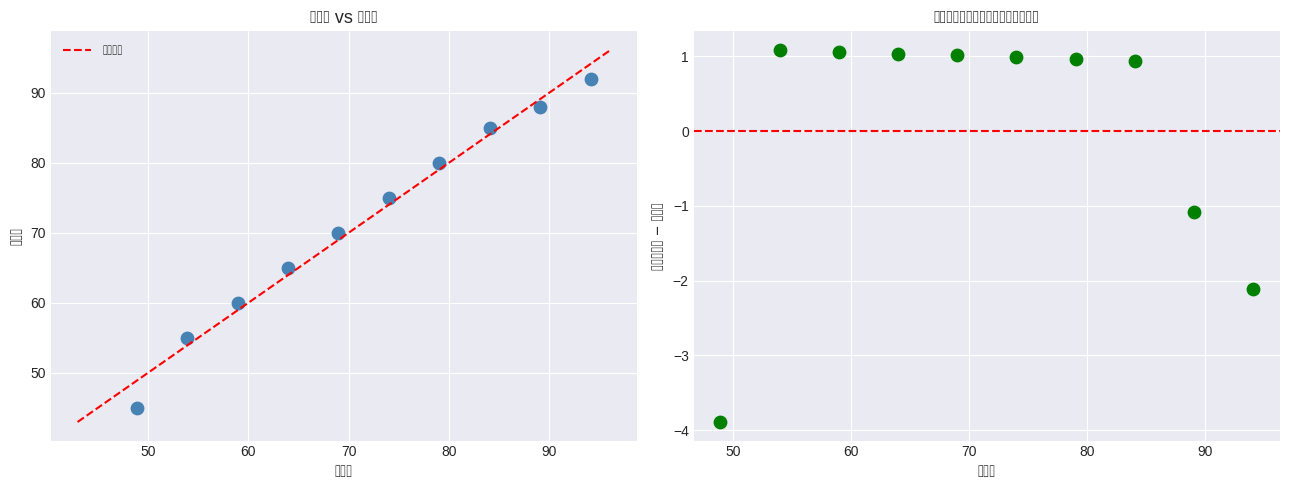

In [8]:
mse  = mean_squared_error(test_scores, y_pred_sk)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(test_scores, y_pred_sk)
r2   = r2_score(test_scores, y_pred_sk)

print("=== 評価指標 ===")
print(f"MSE  = {mse:.4f}")
print(f"RMSE = {rmse:.4f} 点  ← y と同じ単位で誤差を解釈できる")
print(f"MAE  = {mae:.4f} 点")
print(f"R²   = {r2:.4f}  ← モデルがデータの {r2*100:.1f}% を説明")

# 残差プロット
residuals = test_scores - y_pred_sk
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred_sk, test_scores, s=80, color='steelblue')
lims = [min(y_pred_sk.min(), test_scores.min()) - 2,
        max(y_pred_sk.max(), test_scores.max()) + 2]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='完全予測')
axes[0].set_xlabel('予測値', fontsize=12)
axes[0].set_ylabel('実測値', fontsize=12)
axes[0].set_title('予測値 vs 実測値', fontsize=13)
axes[0].legend()

axes[1].scatter(y_pred_sk, residuals, s=80, color='green')
axes[1].axhline(0, color='r', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('予測値', fontsize=12)
axes[1].set_ylabel('残差（実測 − 予測）', fontsize=12)
axes[1].set_title('残差プロット（ランダムなら良好）', fontsize=13)

plt.tight_layout()
plt.show()

---
# 後半：多変量回帰と正則化（実習②）

## 7. 多変量回帰：複数の特徴量を使う

$$y = w_1 x_1 + w_2 x_2 + \cdots + w_p x_p + b$$

**実データ**：scikit-learnに含まれる**糖尿病データセット**を使用します。

- サンプル数：442名
- 特徴量：10個（年齢，BMI，血圧など，いずれも標準化済み）
- 目的変数：1年後の糖尿病の進行度（連続値）

In [9]:
diabetes = load_diabetes()
X_d = diabetes.data
y_d = diabetes.target

# 特徴量名
feature_names = diabetes.feature_names
print("=== 糖尿病データセット ===")
print(f"サンプル数  : {X_d.shape[0]}")
print(f"特徴量数   : {X_d.shape[1]}")
print(f"特徴量名   : {feature_names}")
print(f"\n目的変数の記述統計")
print(pd.Series(y_d, name='糖尿病進行度').describe().round(2))

=== 糖尿病データセット ===
サンプル数  : 442
特徴量数   : 10
特徴量名   : ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

目的変数の記述統計
count    442.00
mean     152.13
std       77.09
min       25.00
25%       87.00
50%      140.50
75%      211.50
max      346.00
Name: 糖尿病進行度, dtype: float64


## 8. 多重共線性の確認：相関行列

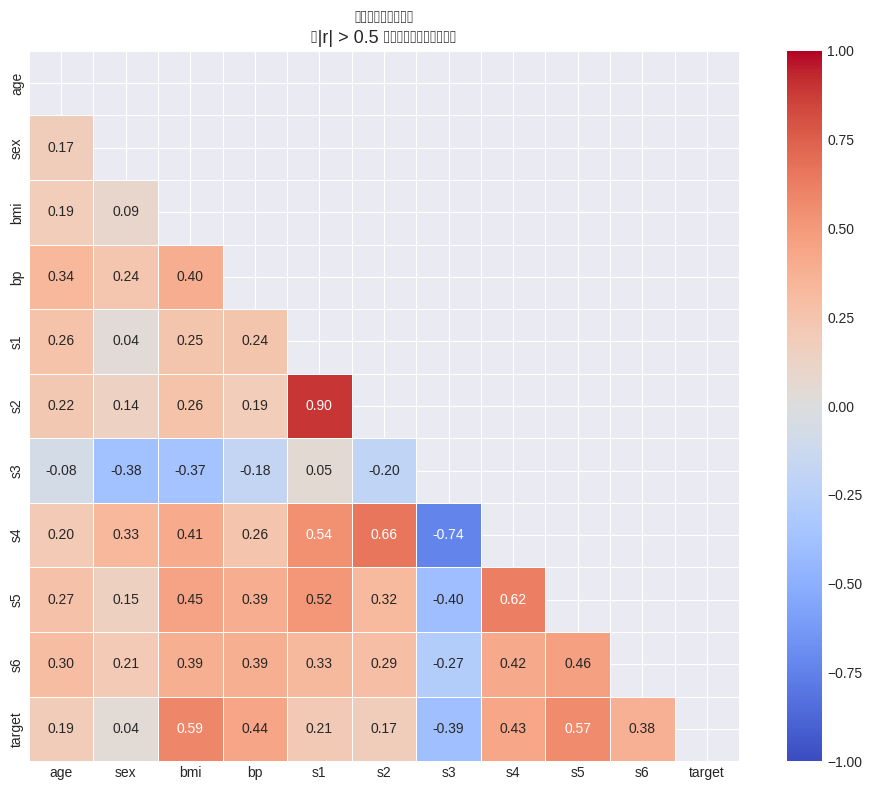

=== 高相関ペア（|r| > 0.5）===
  s1 × s2: r = 0.897
  s1 × s4: r = 0.542
  s1 × s5: r = 0.516
  s2 × s4: r = 0.660
  s3 × s4: r = -0.738
  s4 × s5: r = 0.618


In [10]:
df_d = pd.DataFrame(X_d, columns=feature_names)
df_d['target'] = y_d

plt.figure(figsize=(10, 8))
corr = df_d.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # 上三角を隠す
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title('特徴量間の相関行列\n（|r| > 0.5 は多重共線性の可能性）', fontsize=13)
plt.tight_layout()
plt.show()

# 高相関ペアの抽出
high_corr = []
for i in range(len(feature_names)):
    for j in range(i+1, len(feature_names)):
        r = corr.iloc[i, j]
        if abs(r) > 0.5:
            high_corr.append((feature_names[i], feature_names[j], r))

if high_corr:
    print("=== 高相関ペア（|r| > 0.5）===")
    for f1, f2, r in high_corr:
        print(f"  {f1} × {f2}: r = {r:.3f}")
else:
    print("高相関ペアなし")

## 9. 重回帰（ベースライン）

=== 重回帰（ベースライン）===
テストR²   = 0.4526
テストRMSE = 53.85


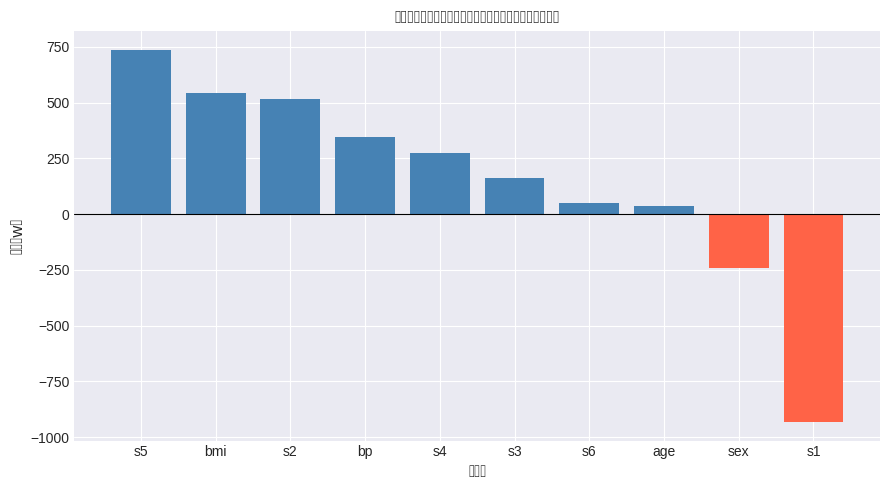

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_d, y_d, test_size=0.2, random_state=42
)

# 重回帰
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

r2_lr   = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("=== 重回帰（ベースライン）===")
print(f"テストR²   = {r2_lr:.4f}")
print(f"テストRMSE = {rmse_lr:.2f}")

# 係数の可視化
coef_df = pd.DataFrame({
    '特徴量': feature_names,
    '係数': lr.coef_
}).sort_values('係数', ascending=False)

plt.figure(figsize=(9, 5))
colors = ['steelblue' if c > 0 else 'tomato' for c in coef_df['係数']]
plt.bar(coef_df['特徴量'], coef_df['係数'], color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('特徴量', fontsize=12)
plt.ylabel('係数（w）', fontsize=12)
plt.title('重回帰の係数（大きいほど目的変数への寄与が大きい）', fontsize=13)
plt.tight_layout()
plt.show()

## 10. 過学習のデモ

特徴量を増やしすぎると訓練データには過剰適合するが，テストデータでは性能が落ちることを確認します。

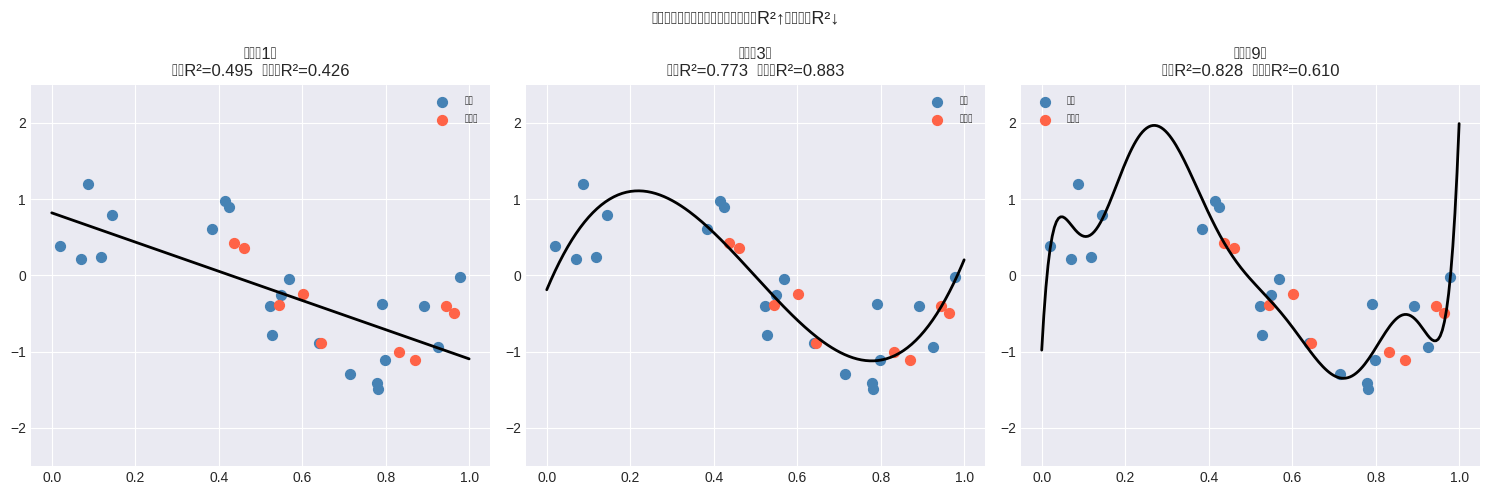

9次多項式は訓練データに完璧に適合するが，テストでは大きく外れる
→ 正則化で複雑なモデルにペナルティを課す


In [12]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# 1次元データで多項式回帰による過学習をデモ
np.random.seed(0)
n = 30
X_demo = np.sort(np.random.uniform(0, 1, n))
y_demo = np.sin(2 * np.pi * X_demo) + np.random.normal(0, 0.3, n)

X_demo_train, X_demo_test, y_demo_train, y_demo_test = train_test_split(
    X_demo.reshape(-1, 1), y_demo, test_size=0.3, random_state=42
)

degrees = [1, 3, 9]
x_plot = np.linspace(0, 1, 200).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, deg in zip(axes, degrees):
    pipe = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    pipe.fit(X_demo_train, y_demo_train)

    r2_train = r2_score(y_demo_train, pipe.predict(X_demo_train))
    r2_test  = r2_score(y_demo_test,  pipe.predict(X_demo_test))

    ax.scatter(X_demo_train, y_demo_train, s=50, color='steelblue', label='訓練')
    ax.scatter(X_demo_test,  y_demo_test,  s=50, color='tomato',    label='テスト')
    ax.plot(x_plot, pipe.predict(x_plot), 'k-', linewidth=2)
    ax.set_title(f'多項式{deg}次\n訓練R²={r2_train:.3f}  テストR²={r2_test:.3f}', fontsize=12)
    ax.set_ylim(-2.5, 2.5)
    ax.legend(fontsize=9)

plt.suptitle('過学習のデモ：次数を上げると訓練R²↑，テストR²↓', fontsize=13)
plt.tight_layout()
plt.show()

print("9次多項式は訓練データに完璧に適合するが，テストでは大きく外れる")
print("→ 正則化で複雑なモデルにペナルティを課す")

## 11. Ridge回帰（L2正則化）

$$L_{\text{Ridge}} = \frac{1}{n}\sum(y_i - \hat{y}_i)^2 + \alpha \sum_j w_j^2$$

- $\alpha$：正則化の強さ（大きいほど係数が縮小される）
- 係数を**ゼロに近づける**が，完全にゼロにはしない

=== Ridge回帰 ===
最適α（交差検証）: 0.0910
テストR²         : 0.4606
テストRMSE       : 53.46


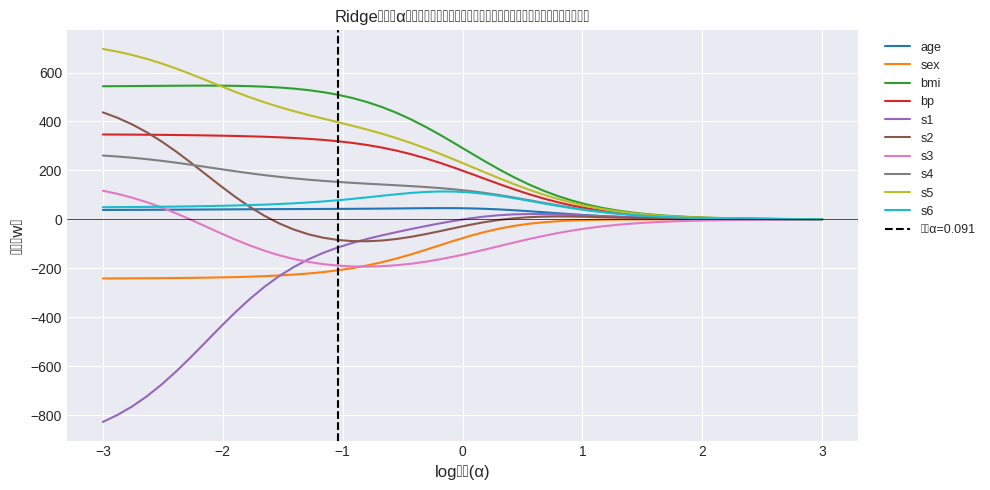

In [13]:
# 交差検証でαを自動選択
alphas = np.logspace(-3, 3, 50)  # 0.001 〜 1000

ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train, y_train)

best_alpha_ridge = ridge_cv.alpha_
y_pred_ridge = ridge_cv.predict(X_test)
r2_ridge     = r2_score(y_test, y_pred_ridge)
rmse_ridge   = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print("=== Ridge回帰 ===")
print(f"最適α（交差検証）: {best_alpha_ridge:.4f}")
print(f"テストR²         : {r2_ridge:.4f}")
print(f"テストRMSE       : {rmse_ridge:.2f}")

# αの変化と係数の変化
coefs_ridge = []
for a in alphas:
    r = Ridge(alpha=a).fit(X_train, y_train)
    coefs_ridge.append(r.coef_)

coefs_ridge = np.array(coefs_ridge)

plt.figure(figsize=(10, 5))
for i, name in enumerate(feature_names):
    plt.plot(np.log10(alphas), coefs_ridge[:, i], label=name)
plt.axvline(np.log10(best_alpha_ridge), color='k', linestyle='--',
            linewidth=1.5, label=f'最適α={best_alpha_ridge:.3f}')
plt.axhline(0, color='k', linewidth=0.5)
plt.xlabel('log₁₀(α)', fontsize=12)
plt.ylabel('係数（w）', fontsize=12)
plt.title('Ridge回帰：αの増加とともに係数が縮小（ゼロには近づくがゼロにはならない）', fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 12. Lasso回帰（L1正則化）

$$L_{\text{Lasso}} = \frac{1}{n}\sum(y_i - \hat{y}_i)^2 + \alpha \sum_j |w_j|$$

- 係数を**完全にゼロ**にできる → **自動的な特徴量選択**
- 不要な特徴量を除外し，解釈しやすいモデルが得られる

In [ ]:
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_train, y_train)

best_alpha_lasso = lasso_cv.alpha_
y_pred_lasso = lasso_cv.predict(X_test)
r2_lasso     = r2_score(y_test, y_pred_lasso)
rmse_lasso   = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print("=== Lasso回帰 ===")
print(f"最適α（交差検証）: {best_alpha_lasso:.4f}")
print(f"テストR²         : {r2_lasso:.4f}")
print(f"テストRMSE       : {rmse_lasso:.2f}")

zero_coefs = np.sum(lasso_cv.coef_ == 0)
print(f"\nゼロになった係数 : {zero_coefs}/{len(feature_names)} 個")

# αの変化と係数の変化
coefs_lasso = []
for a in alphas:
    l = Lasso(alpha=a, max_iter=10000).fit(X_train, y_train)
    coefs_lasso.append(l.coef_)

coefs_lasso = np.array(coefs_lasso)

plt.figure(figsize=(10, 5))
for i, name in enumerate(feature_names):
    plt.plot(np.log10(alphas), coefs_lasso[:, i], label=name)
plt.axvline(np.log10(best_alpha_lasso), color='k', linestyle='--',
            linewidth=1.5, label=f'最適α={best_alpha_lasso:.3f}')
plt.axhline(0, color='k', linewidth=0.5)
plt.xlabel('log₁₀(α)', fontsize=12)
plt.ylabel('係数（w）', fontsize=12)
plt.title('Lasso回帰：αの増加とともに係数が完全にゼロになる（特徴量選択）', fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 13. 3手法の総合比較

In [ ]:
results = pd.DataFrame({
    '手法': ['重回帰（ベースライン）', 'Ridge', 'Lasso'],
    'テストR²':   [r2_lr,    r2_ridge,    r2_lasso],
    'テストRMSE': [rmse_lr,  rmse_ridge,  rmse_lasso],
    'ゼロ係数数': [
        np.sum(lr.coef_        == 0),
        np.sum(ridge_cv.coef_  == 0),
        np.sum(lasso_cv.coef_  == 0)
    ]
})
print("=== 3手法の比較 ===")
print(results.round(4).to_string(index=False))

In [ ]:
# 係数の比較プロット
x = np.arange(len(feature_names))
width = 0.27

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, lr.coef_,       width, label='重回帰',  alpha=0.8, color='steelblue')
ax.bar(x,          ridge_cv.coef_, width, label='Ridge',   alpha=0.8, color='orange')
ax.bar(x + width,  lasso_cv.coef_, width, label='Lasso',   alpha=0.8, color='green')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(feature_names)
ax.set_ylabel('係数（w）', fontsize=12)
ax.set_title('3手法の係数比較\n（Lassoはゼロになった係数がある）', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print("\n=== Lasso：非ゼロの係数のみ（選択された特徴量）===")
for name, coef in zip(feature_names, lasso_cv.coef_):
    if coef != 0:
        print(f"  {name}: {coef:.4f}")

---
## 14. 本日のまとめ

**前半：線形回帰**
- モデル：$y = wx + b$
- 最適化：最小二乗法（MSEを最小化するw，bを求める）
- 評価：MSE，RMSE，R²
- 実装：scikit-learnの `LinearRegression` で3行

**後半：多変量回帰と正則化**
- 特徴量が複数 → 重回帰 $y = w_1x_1 + \cdots + w_px_p + b$
- 多重共線性：特徴量間の強い相関が問題
- 過学習：訓練データへの過剰適合
- Ridge（L2）：係数を縮小，多重共線性に有効
- Lasso（L1）：係数をゼロにできる，特徴量選択
- αの選択：交差検証（`RidgeCV`，`LassoCV`）で自動化

**次回：ロジスティック回帰**
- なぜ線形回帰では分類できないか
- Sigmoid関数と確率の解釈
- 交差エントロピー損失

---
## 準備学習課題

**課題1**（100字程度・必須）  
RidgeとLassoの違いを，ペナルティの形と係数の挙動の観点から説明せよ。

**課題2**（100字程度・必須）  
R²が0.95の場合と0.50の場合では，それぞれどのような意味を持つか説明せよ。

**課題3**（発展・任意）  
ElasticNetはRidgeとLassoを組み合わせた手法である。scikit-learnのドキュメントを参照し，糖尿病データで実装してR²を確認せよ。

---

### 解答欄

**課題1**:


**課題2**:


**課題3（任意）**:


In [ ]:
# 課題3 作業スペース（任意）
from sklearn.linear_model import ElasticNet, ElasticNetCV

# ここにコードを書く


---
## 参考文献

1. Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer.
2. Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly.
3. scikit-learn: Linear Models — https://scikit-learn.org/stable/modules/linear_model.html

---
*人工知能I 第3回実習ノートブック（改定案A）| 担当：浅川伸一*